# scRNA-seq

In [635]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sn
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

scvi.settings.seed = 30

Seed set to 30


### Annotate Single Cells with Cell Type Label

In [636]:
######################################################## load reference
ref_data = sc.read_h5ad('TS_Mammary.h5ad')
print(ref_data)

######################################################## load data
file = 'scrnaseq_processed_data.h5ad' ### <--- data
dat1 = sc.read_h5ad(file)
print(dat1)

######################################################## concatenate data
dat1 = dat1.concatenate(ref_data)

AnnData object with n_obs × n_vars = 11375 × 58870
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 919 × 29733
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_

In [637]:
dat1.obs

,Sample,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,batch
CID3586_AGCTTGATCGGCGCTA-0,scrnaseq,False,924.0,1662.0,125.0,7.521059,261.0,15.703972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3586_ATCATCTAGGGATACC-0,scrnaseq,False,828.0,1593.0,84.0,5.273070,196.0,12.303829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3586_ATGGGAGAGGAGCGAG-0,scrnaseq,False,966.0,1959.0,32.0,1.633487,371.0,18.938234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3586_ATGTGTGAGTCAATAG-0,scrnaseq,False,767.0,1363.0,105.0,7.703595,248.0,18.195158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3586_ATTATCCGTCCTAGCG-0,scrnaseq,False,1035.0,2045.0,201.0,9.828851,272.0,13.300734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_P16_L001-1,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,Mammary,smartseq2,TSP4,nan,416893.0,456.0,fibroblast of breast,Fibroblasts (Lipofibroblasts),True,stromal,female,1
TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_P19_L001-1,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,Mammary,smartseq2,TSP4,nan,115929.0,509.0,fibroblast of breast,Fibroblasts (Lipofibroblasts),True,stromal,female,1
TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_P20_L001-1,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,Mammary,smartseq2,TSP4,nan,1673903.0,1859.0,fibroblast of breast,Fibroblasts (Lipofibroblasts),True,stromal,female,1
TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_P3_L001-1,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,Mammary,smartseq2,TSP4,nan,459043.0,1063.0,fibroblast of breast,Fibroblasts (Lipofibroblasts),True,stromal,female,1


In [638]:
dat1.obs.head()

,Sample,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,batch
CID3586_AGCTTGATCGGCGCTA-0,scrnaseq,False,924.0,1662.0,125.0,7.521059,261.0,15.703972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3586_ATCATCTAGGGATACC-0,scrnaseq,False,828.0,1593.0,84.0,5.273070,196.0,12.303829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3586_ATGGGAGAGGAGCGAG-0,scrnaseq,False,966.0,1959.0,32.0,1.633487,371.0,18.938234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3586_ATGTGTGAGTCAATAG-0,scrnaseq,False,767.0,1363.0,105.0,7.703595,248.0,18.195158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0
CID3586_ATTATCCGTCCTAGCG-0,scrnaseq,False,1035.0,2045.0,201.0,9.828851,272.0,13.300734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,0


In [639]:
dat1_copy = dat1.copy()

In [640]:
######################################################## normalize data
dat1.layers["counts"] = dat1.X.copy()
sc.pp.normalize_total(dat1, target_sum = 10000)
sc.pp.log1p(dat1)
dat1.raw = dat1

print(dat1)
######################################################## filter
sc.pp.highly_variable_genes(dat1, flavor = 'seurat_v3', n_top_genes=4000, layer = 'counts', subset = True)
print(dat1)

AnnData object with n_obs × n_vars = 12294 × 20574
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'batch'
    var: 'gene_symbol-1', 'feature_type-1', 'ensemblid-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'mean-1', 'std-1'
    uns: 'log1p'
    layers: 'counts'
AnnData object with n_obs × n_vars = 12294 × 4000
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'batch'
    var: 'gene_symbol-1', 'feature_type-1', 'ensemblid-

In [641]:
######################################################## train model
scvi.model.SCVI.setup_anndata(dat1, layer = 'counts')
vae = scvi.model.SCVI(dat1) ### initialize the model
vae.train()

######################################################## predict label
dat1.obs['cell_ontology_class'] = dat1.obs['cell_ontology_class'].cat.add_categories('Unknown')
dat1.obs = dat1.obs.fillna(value = {'cell_ontology_class': 'Unknown'})

lvae = scvi.model.SCANVI.from_scvi_model(vae, adata = dat1, unlabeled_category = 'Unknown', labels_key = 'cell_ontology_class')
lvae.train()

dat1.obs['predicted'] = lvae.predict(dat1)
dat1.obs['bc2'] = dat1.obs.index.map(lambda x: x[:-2])

######################################################## store labels in a dictionary
cell_mapper = dict(zip(dat1.obs.bc2, dat1.obs.predicted))

######################################################## map to data
dat1 = sc.read_h5ad(file)
dat1.var_names_make_unique()
dat1.obs['cell_type'] = dat1.obs.index.map(cell_mapper)
dat1.obs.groupby('Sample').count()
dat1.obs

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


INFO     Training for 10 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training:   0%|          | 0/10 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


,Sample,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,cell_type
CID3586_AGCTTGATCGGCGCTA,scrnaseq,False,924,1662.0,125.0,7.521059,261.0,15.703972,vein endothelial cell
CID3586_ATCATCTAGGGATACC,scrnaseq,False,828,1593.0,84.0,5.273070,196.0,12.303829,vein endothelial cell
CID3586_ATGGGAGAGGAGCGAG,scrnaseq,False,966,1959.0,32.0,1.633487,371.0,18.938234,vein endothelial cell
CID3586_ATGTGTGAGTCAATAG,scrnaseq,False,767,1363.0,105.0,7.703595,248.0,18.195158,vein endothelial cell
CID3586_ATTATCCGTCCTAGCG,scrnaseq,False,1035,2045.0,201.0,9.828851,272.0,13.300734,vein endothelial cell
...,...,...,...,...,...,...,...,...,...
CID3586_TGCTGCTAGCTAGTCT,scrnaseq,False,1092,3145.0,373.0,11.860096,270.0,8.585056,luminal epithelial cell of mammary gland
CID3586_TTAGTTCGTCTTCGTC,scrnaseq,False,903,1818.0,125.0,6.875688,310.0,17.051706,luminal epithelial cell of mammary gland
CID3586_TTCCCAGCATCGGGTC,scrnaseq,False,1737,4183.0,143.0,3.418599,665.0,15.897681,luminal epithelial cell of mammary gland
CID3586_TTCTTAGAGAGTCGGT,scrnaseq,False,2218,4922.0,553.0,11.235270,358.0,7.273466,luminal epithelial cell of mammary gland


### Data Analysis

In [642]:
dat1

AnnData object with n_obs × n_vars = 919 × 29733
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type'

In [643]:
############################### remove cells that do not meet the required minium number of genes
sc.pp.filter_cells(dat1, min_genes = 200) ### <-- 100

############################### remove genes that do not meet the required minium number of cells
sc.pp.filter_genes(dat1, min_cells = 10) ### <--- 10
dat1

AnnData object with n_obs × n_vars = 919 × 11318
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type', 'n_genes'
    var: 'n_cells'

In [644]:
######################################################## normalize data
dat1.layers['counts'] = dat1.X.copy()
sc.pp.normalize_total(dat1, target_sum = 10000)
sc.pp.log1p(dat1)
dat1.raw = dat1

print(dat1)
######################################################## filter
sc.pp.highly_variable_genes(dat1, flavor='seurat_v3', n_top_genes=2000, layer='counts', subset=True)
print(dat1)

AnnData object with n_obs × n_vars = 919 × 11318
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type', 'n_genes'
    var: 'n_cells'
    uns: 'log1p'
    layers: 'counts'
AnnData object with n_obs × n_vars = 919 × 2000
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type', 'n_genes'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'


In [645]:
######################################################## train model
scvi.model.SCVI.setup_anndata(dat1, layer='counts',
                              categorical_covariate_keys=['Sample'],
                              #continuous_covariate_keys=['pct_counts_mt', 'total_counts', 'pct_counts_ribo'])
                              continuous_covariate_keys=['total_counts', 'pct_counts_ribo'])

model = scvi.model.SCVI(dat1)
model.train()

######################################################## prepare data for clustering
model.get_latent_representation().shape
dat1.obsm['X_scVI'] = model.get_latent_representation()
dat1.layers['scvi_normalized'] = model.get_normalized_expression(library_size=10000)

sc.pp.neighbors(dat1, use_rep = 'X_scVI')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [ ]:
dat2_copy = dat1.copy()

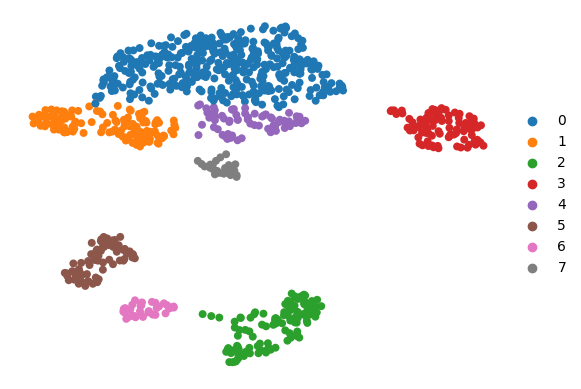

In [660]:
######################################################## plot umap, based on leiden clustering
sc.tl.umap(dat1)
sc.tl.leiden(dat1, resolution = 0.35)

sc.pl.umap(dat1, color = ['leiden'], frameon = False, title = "") ### leiden clustering
#sc.pl.umap(dat1, color = ['Sample'], frameon = False, title = "", save='UMAP_sample_scrnaseq.png') ### sample

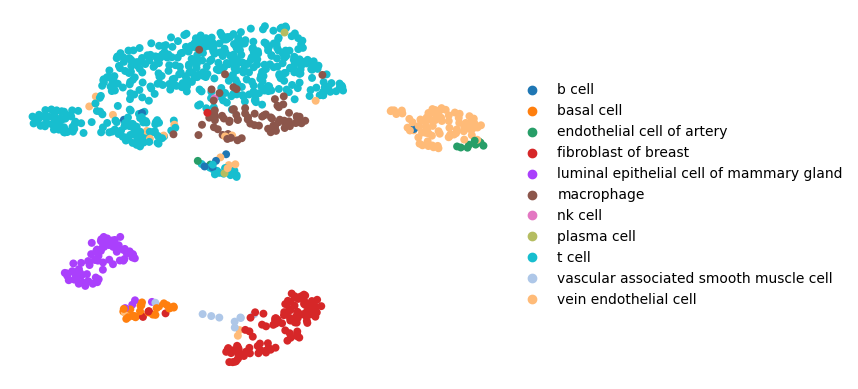

In [661]:
######################################################## plot umap, based on labelled cell type annotation from Tabula Sapiens Consortum
sc.pl.umap(dat1, color = 'cell_type', frameon = False, title = "")

In [662]:
dat1

AnnData object with n_obs × n_vars = 919 × 2000
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'cell_type_colors', 'rank_genes_groups'
    obsm: '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scVI', 'X_umap'
    layers: 'counts', 'scvi_normalized'
    obsp: 'distances', 'connectivities'

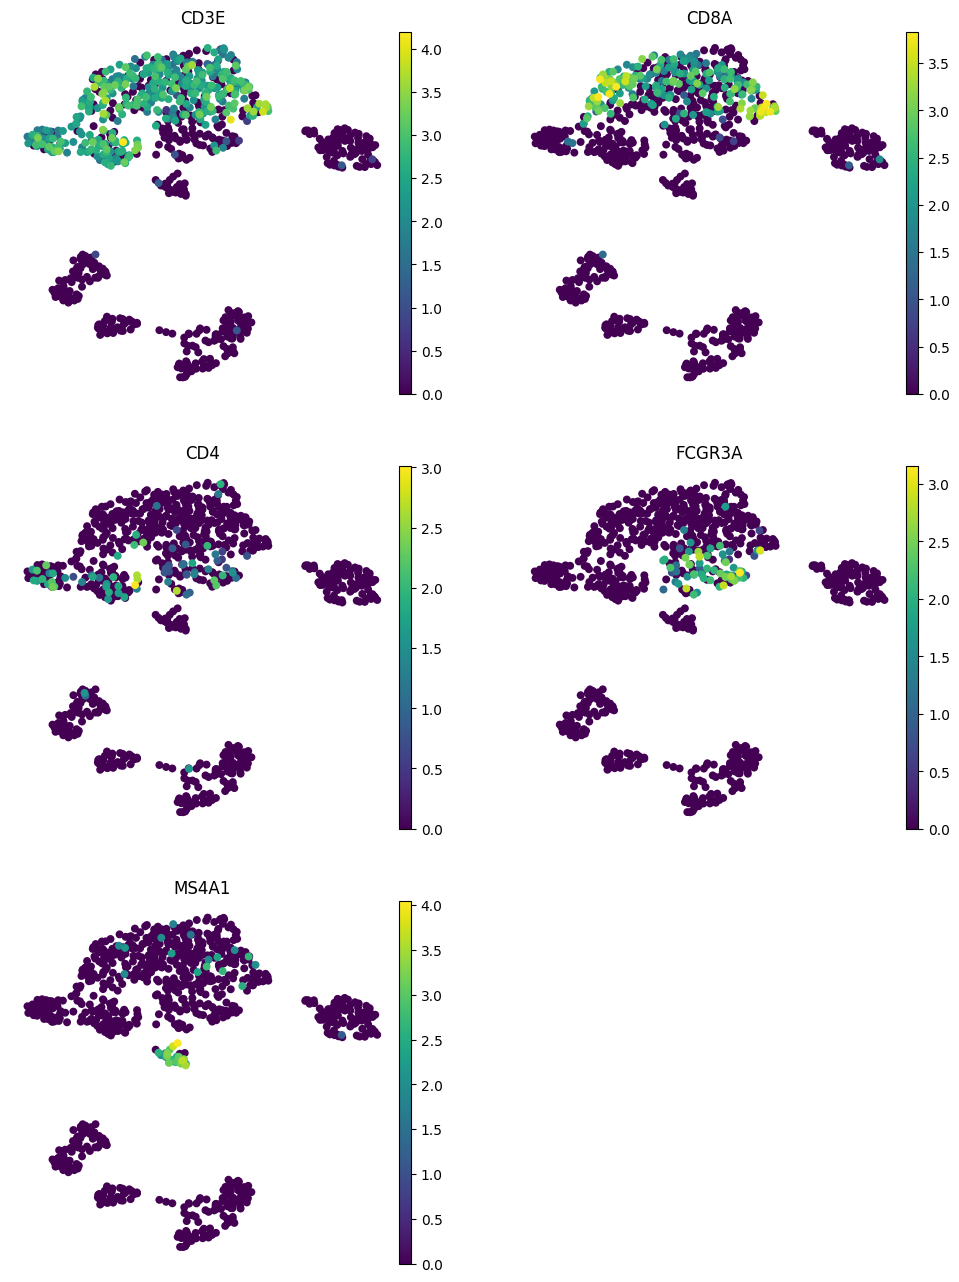

In [663]:
######################################################## plot biomarker genes
fig, axs = plt.subplots(3,2, figsize=(12,16))

sc.pl.umap(dat1, color = ['CD3E'], frameon = False, ax=axs[0,0], show=False) ### T cell
sc.pl.umap(dat1, color = ['CD8A'], frameon = False, ax=axs[0,1], show=False) ### CD8 T cell
sc.pl.umap(dat1, color = ['CD4'], frameon = False, ax=axs[1,0], show=False) ### CD4 T cell
sc.pl.umap(dat1, color = ['FCGR3A'] , frameon = False, ax=axs[1,1], show=False) ### macrophage
sc.pl.umap(dat1, color = ['MS4A1'], frameon = False, ax=axs[2,0], show=False) ### B cell
plt.delaxes(axs[2,1])
plt.savefig('biomarkers_scrnaseq_1.png')

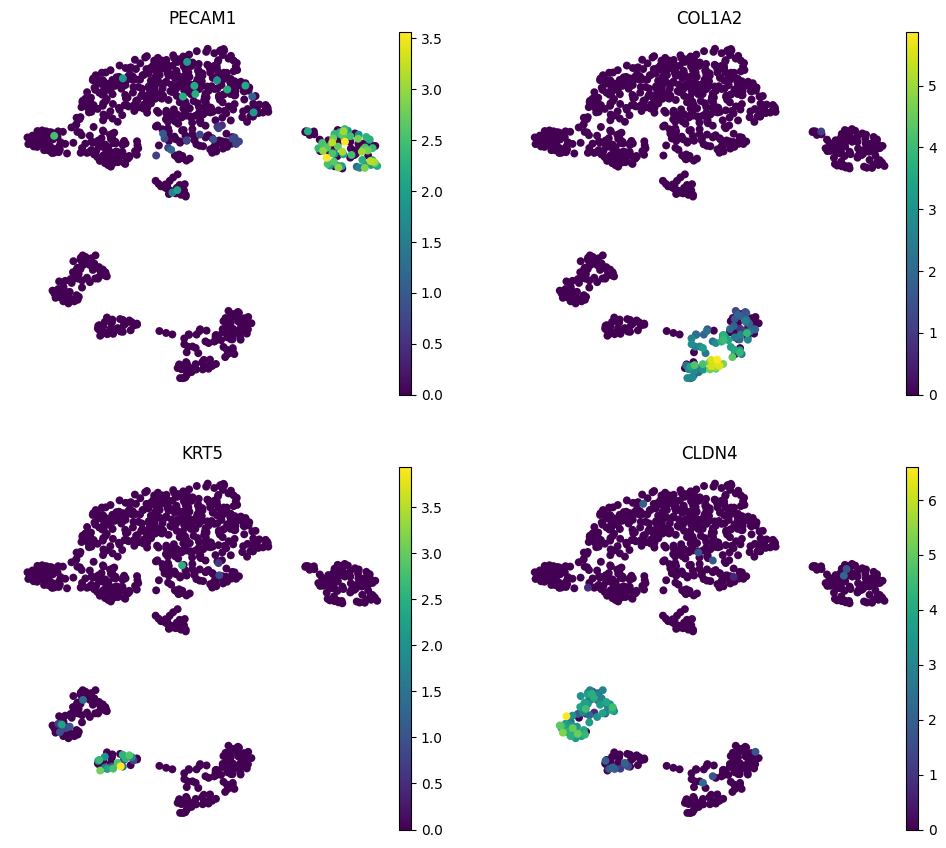

In [664]:
######################################################## plot biomarker genes
fig, axs = plt.subplots(3,2, figsize=(12,16))

sc.pl.umap(dat1, color = ['PECAM1'] , frameon = False, ax=axs[0,0], show=False) ### endothelial cell
sc.pl.umap(dat1, color = ['COL1A2'] , frameon = False, ax=axs[0,1], show=False) ### fibroblast cell
sc.pl.umap(dat1, color = ['KRT5'], frameon = False, ax=axs[1,0], show=False) ### basal cell
sc.pl.umap(dat1, color = ['CLDN4'], frameon = False, ax=axs[1,1], show=False) ### luminal cell
plt.delaxes(axs[2,0])
plt.delaxes(axs[2,1])
plt.savefig('biomarkers_scrnaseq_2.png')

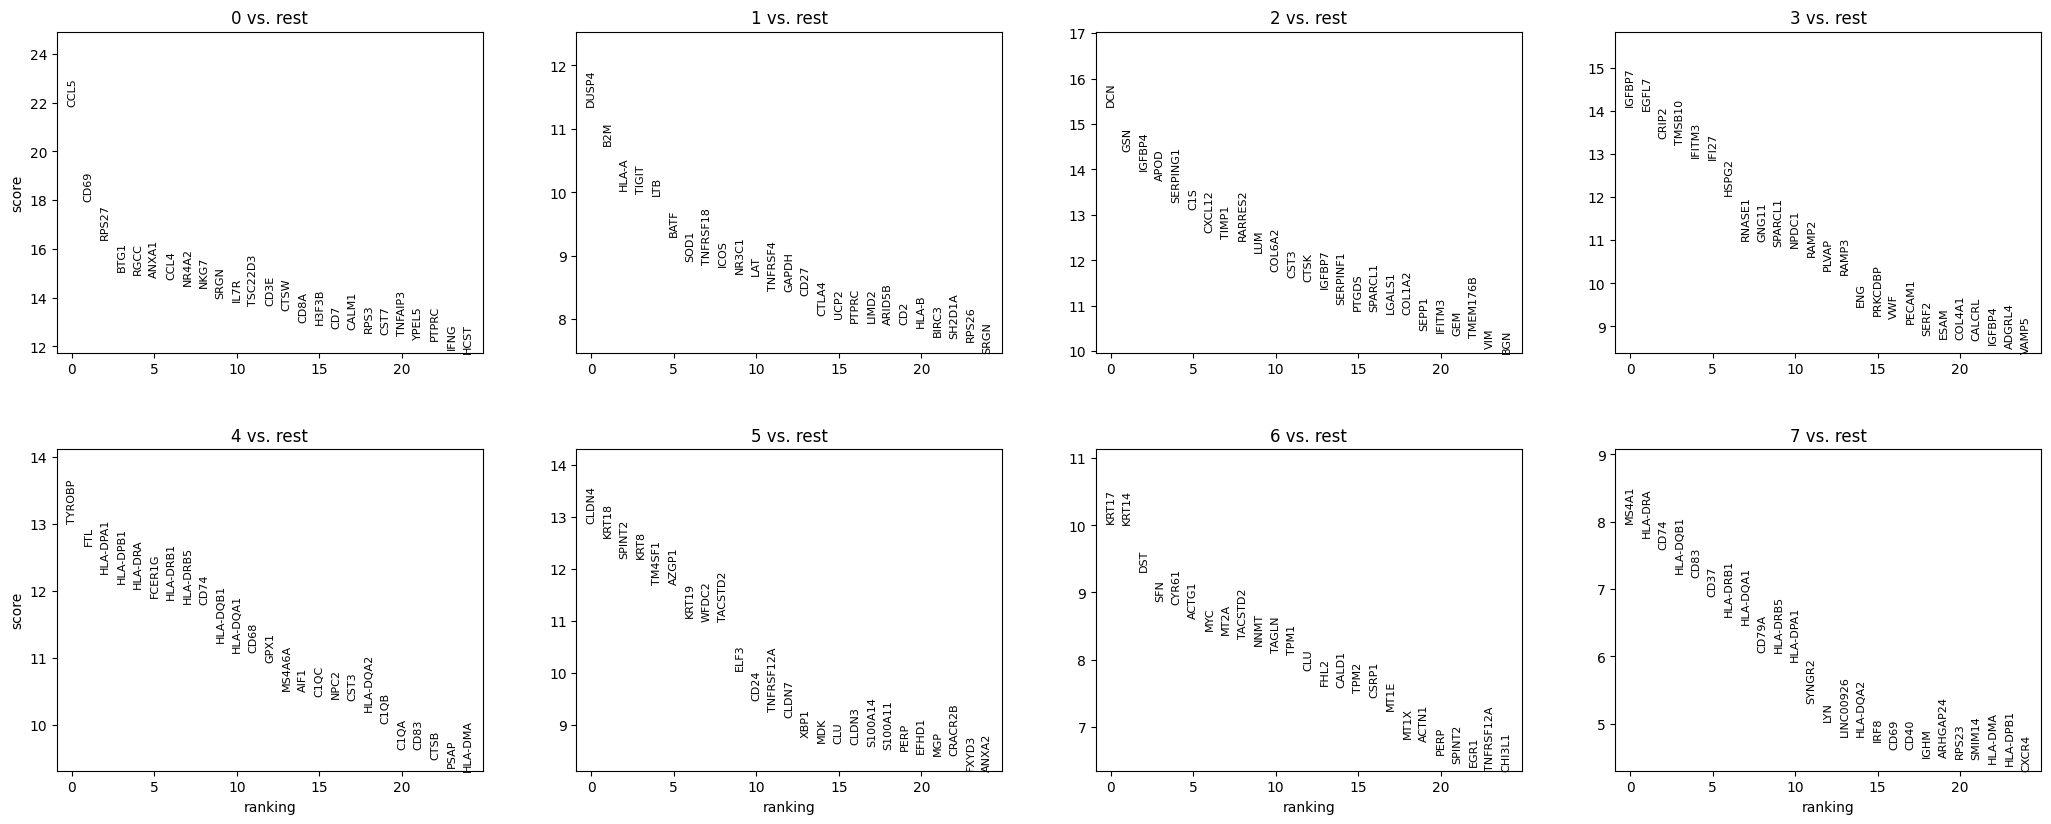

In [665]:
######################################################## compute differential expression by Wilcoxon test
sc.tl.rank_genes_groups(dat1, 'leiden', method="wilcoxon")
sc.pl.rank_genes_groups(dat1, n_genes=25, sharey=False)

######################################################## filter by adjusted p-values and log-fold-changes from Wilcoxon test
markers_all = sc.get.rank_genes_groups_df(dat1, None)
markers_all.to_csv('biomarker_raw.csv', index=False)
markers = markers_all[(markers_all.pvals_adj < 0.05) & (markers_all.logfoldchanges > 0.5)]
#markers.to_csv('biomarker_processed.csv', index=False)

In [666]:
df = sc.get.rank_genes_groups_df(dat1, group='0')
print(df)
#df.to_csv("cluster0_ranked_gene.scsv", index=False)

        names     scores  logfoldchanges          pvals      pvals_adj
0        CCL5  21.869820        7.042774  5.035558e-106  5.699245e-102
1        CD69  17.958508        4.188605   4.117250e-72   2.329952e-68
2       RPS27  16.393179        1.080685   2.139601e-60   8.072000e-57
3        BTG1  15.102328        2.080812   1.563155e-51   4.422946e-48
4        RGCC  14.959236        3.158355   1.355738e-50   3.068848e-47
...       ...        ...             ...            ...            ...
11313     GSN  -9.954534       -4.843606   2.409500e-23   6.493028e-21
11314     MGP  -9.988765       -7.434566   1.706951e-23   4.712018e-21
11315  IGFBP4 -11.674157       -4.810560   1.727705e-31   6.983631e-29
11316  IFITM3 -12.264522       -2.394150   1.404385e-34   6.622846e-32
11317    CST3 -13.066694       -4.806877   5.103575e-39   3.850817e-36

[11318 rows x 5 columns]


In [670]:
######################################################## compute differential expression by scvi-DE
markers_scvi = model.differential_expression(adata=dat1, groupby='leiden')

######################################################## filter by FDR and log-fold-change mean from scvi-DE
markers_scvi = markers_scvi[(markers_scvi['is_de_fdr_0.05']) & (markers_scvi.lfc_mean > 0.5)]

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


DE...:   0%|          | 0/8 [00:00<?, ?it/s]

In [671]:
markers_scvi

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
CXCL13,0.9720,0.0280,3.547151,0.020285,0.000623,0.001388,0.25,5.782196,5.637814,2.889743,...,9.333335,0.151899,0.387597,0.015190,312.206726,1.942677,True,1 vs Rest,1,Rest
FAAH2,0.9624,0.0376,3.242426,0.002060,0.000162,0.001388,0.25,3.960087,3.909509,1.623772,...,0.496124,0.037975,0.271318,0.030380,16.787659,0.757684,True,1 vs Rest,1,Rest
BATF,0.9582,0.0418,3.132160,0.005254,0.000428,0.001388,0.25,4.593950,4.428479,2.419194,...,1.542636,0.145570,0.565891,0.078481,49.280861,2.453198,True,1 vs Rest,1,Rest
SELL,0.9530,0.0470,3.009467,0.002893,0.000550,0.001388,0.25,3.056878,2.735870,1.886032,...,0.751938,0.083544,0.387597,0.054430,21.588001,2.180180,True,1 vs Rest,1,Rest
TRBV24-1,0.9468,0.0532,2.879029,0.002107,0.000101,0.001388,0.25,5.426245,5.244553,2.559567,...,0.178295,0.010127,0.046512,0.005063,5.626916,0.348661,True,1 vs Rest,1,Rest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IRF8,0.9586,0.0414,3.142193,0.004130,0.000506,0.003851,0.25,3.563748,3.365997,1.768421,...,1.678571,0.147026,0.571429,0.072952,40.989361,1.379735,True,7 vs Rest,7,Rest
MS4A1,0.9444,0.0556,2.832366,0.004504,0.000154,0.003851,0.25,5.659629,5.747041,2.161791,...,3.428571,0.024691,0.892857,0.019080,88.187500,0.817172,True,7 vs Rest,7,Rest
CD74,0.9434,0.0566,2.813481,0.051625,0.010528,0.003851,0.25,3.017995,3.133698,1.700597,...,35.107143,20.616158,1.000000,0.645342,850.058838,144.081375,True,7 vs Rest,7,Rest
HLA-DRB5,0.9272,0.0728,2.544453,0.013273,0.002153,0.003851,0.25,4.151932,4.236670,2.498759,...,7.142857,5.158251,0.928571,0.329966,130.928879,30.508450,True,7 vs Rest,7,Rest


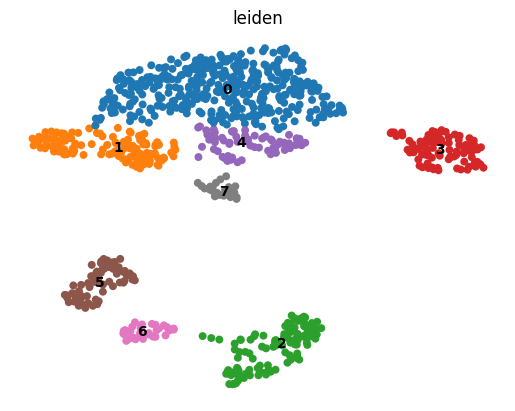

In [672]:
sc.pl.umap(dat1, color = ['leiden'], frameon = False, legend_loc = "on data")

In [673]:
dat1

AnnData object with n_obs × n_vars = 919 × 2000
    obs: 'Sample', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'cell_type', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'cell_type_colors', 'rank_genes_groups'
    obsm: '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scVI', 'X_umap'
    layers: 'counts', 'scvi_normalized'
    obsp: 'distances', 'connectivities'

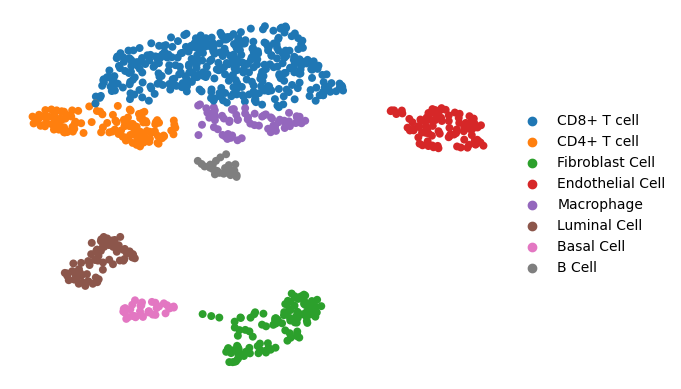

In [674]:
######################################################## labelling leiden clusters
Type = {
"0":'CD8+ T cell',
"1":'CD4+ T cell',
"2":'Fibroblast Cell',
"3":'Endothelial Cell',
"4":'Macrophage',
"5":'Luminal Cell',
"6":'Basal Cell',
"7":'B Cell'
}
dat1.obs['Type'] = dat1.obs.leiden.map(Type)

######################################################## plot
sc.pl.umap(dat1, color = ['Type'], frameon = False, title="",  save='UMAP_scrnaseq.png')

In [675]:
######################################################## wilcoxon DE
######################################################## Load APA gene list
polyadb_list = pd.read_csv('polyadb4_TR_gene_list.csv')['gene_symbol'].tolist()

######################################################## filter for adjusted p-value < 0.05 and log-fold-change > 0.5
de_genes_w = markers[(markers['pvals_adj'] < 0.05) & (markers['logfoldchanges'] > 0.5)].copy()
print(de_genes_w)
num_unique_genes = len(de_genes_w['names'].unique())
print(f"Number of significant DE genes (Wilcoxon): {num_unique_genes}")

######################################################## subset for HVGs
hvg_genes = dat1.var_names[dat1.var['highly_variable']]
de_genes_w_hvg = de_genes_w[de_genes_w['names'].isin(hvg_genes)].copy()
num_unique_hvg_de = len(de_genes_w_hvg['names'].unique())
print(f"Number of significant DE genes belonging to HVGs: {num_unique_hvg_de}")

######################################################## subset for APA genes
apa_de_genes_w = [g for g in polyadb_list if g in de_genes_w_hvg['names'].values]
num_unique_hvg_de_apa = len(set(apa_de_genes_w))
print(f"Number of APA DE genes belonging to HVGs: {num_unique_hvg_de_apa}")

######################################################## save
de_genes_w_hvg.to_csv("de_genes_w_hvg_filtered.csv", index=False)

matched_w = dat1[:, apa_de_genes_w]

      group  names     scores  logfoldchanges          pvals      pvals_adj
0         0   CCL5  21.869820        7.042774  5.035558e-106  5.699245e-102
1         0   CD69  17.958508        4.188605   4.117250e-72   2.329952e-68
2         0  RPS27  16.393179        1.080685   2.139601e-60   8.072000e-57
3         0   BTG1  15.102328        2.080812   1.563155e-51   4.422946e-48
4         0   RGCC  14.959236        3.158355   1.355738e-50   3.068848e-47
...     ...    ...        ...             ...            ...            ...
79257     7    REL   3.955179        1.995882   7.647730e-05   2.111146e-02
79258     7   STK4   3.909264        1.969499   9.257758e-05   2.494745e-02
79259     7  BANK1   3.854673        9.439402   1.158845e-04   3.050188e-02
79260     7  CNPY3   3.847442        2.579305   1.193574e-04   3.070199e-02
79261     7   CKS2   3.726690        1.797974   1.940109e-04   4.574616e-02

[2168 rows x 6 columns]
Number of significant DE genes (Wilcoxon): 1718
Number of signi

In [676]:
######################################################## scvi-DE
######################################################## Load APA gene list
polyadb_list = pd.read_csv('polyadb4_TR_gene_list.csv')['gene_symbol'].tolist()

######################################################## DE (markers_scvi)
markers_scvi.index.name = 'gene'

######################################################## filter for DE genes
de_genes = markers_scvi[(markers_scvi['is_de_fdr_0.05']) &(markers_scvi['lfc_mean'] > 0.5)].copy()

######################################################## subset for APA genes
apa_de_genes = [g for g in polyadb_list if g in de_genes.index and g in dat1.var_names]

######################################################## sort by lfc_mean
apa_de_genes = (de_genes.loc[apa_de_genes].sort_values('lfc_mean', ascending=False).index.tolist())
#pd.DataFrame(apa_de_genes, columns=['gene']).to_csv("apa_de_genes_sorted.csv", index=False)

######################################################## subet HVGs
hvg_genes = dat1.var_names[dat1.var['highly_variable']]
apa_de_genes_hvg = [g for g in apa_de_genes if g in hvg_genes]
#num_unique_apa_hvg = len(set(apa_de_genes_hvg))
#print(f"Number of unique APA DE genes within HVGs: {num_unique_apa_hvg}")

########################################################
matched_s = dat1[:, apa_de_genes_hvg]
print(f"Number of APA DE genes belonging to HVGs (SVCI): {len(matched_s.var_names.unique().tolist())}")
print("APA genes:", matched.var_names.unique().tolist())
#sc.pl.dotplot(matched,var_names=apa_de_genes, groupby="cell_type_2", swap_axes=True,save='_apa_genes_from_scvi_DE.png')

Number of APA DE genes belonging to HVGs (SVCI): 160
APA genes: ['DCN', 'AZGP1', 'KRT17', 'CD24', 'KRT19', 'HSPG2', 'KRT14', 'LUM', 'WFDC2', 'TAGLN', 'APOD', 'CCL19', 'MGP', 'RAMP3', 'VWF', 'KRT5', 'CLDN4', 'FABP4', 'CXCL14', 'RARRES2', 'CHI3L1', 'IGFBP7', 'RBP7', 'IGF2', 'TACSTD2', 'SFN', 'ADGRL4', 'KRT6B', 'CRYAB', 'CLDN3', 'AQP1', 'MGST1', 'RARRES1', 'SAA1', 'MFAP4', 'PLVAP', 'GNG11', 'RAMP2', 'EMCN', 'FXYD3', 'ESAM', 'EGFL7', 'MMP7', 'C1QB', 'CXCL12', 'SERPINF1', 'KRT7', 'TM4SF1', 'LTF', 'C1S', 'KRT8', 'SPARC', 'MYLK', 'ARHGAP29', 'COL17A1', 'CRIP2', 'LAMC2', 'DST', 'ALPL', 'C1QC', 'TIMP3', 'CXCL13', 'SPINT2', 'MS4A1', 'SEMA3C', 'NNMT', 'PECAM1', 'CNN1', 'RNASE1', 'KRT18', 'C1QA', 'BCAM', 'TPM1', 'EFEMP1', 'TPM2', 'CALCRL', 'MYL9', 'ACTA2', 'SERPING1', 'CLDN7', 'ELF3', 'ADAM15', 'KRT15', 'TFAP2C', 'FHL2', 'THBD', 'CTLA4', 'CRABP2', 'ENG', 'SPARCL1', 'A2M', 'NGFR', 'IFI27', 'PTHLH', 'DKK3', 'CXADR', 'PTN', 'GSN', 'HLA-DRA', 'RCAN1', 'PLAT', 'BATF', 'PLPP1', 'CD27', 'WLS', 'TNS4', 'H

Wilcoxon: 850
SCVI: 161
Number of shared genes: 154
Shared genes: ['ADAM15', 'AIF1', 'AQP1', 'ATP1B1', 'BATF', 'BCAM', 'C15orf48', 'C1QA', 'C1QB', 'C1QC', 'C1S', 'CAV1', 'CD27', 'CD83', 'CLDN4', 'CNN1', 'CRACR2B', 'CRIP2', 'CTLA4', 'CXADR', 'CXCL13', 'EGFL7', 'ELF3', 'FAAH2', 'FABP5', 'FTL', 'FXYD3', 'GNG11', 'GSN', 'HLA-DPB1', 'HLA-DQA1', 'HLA-DRA', 'ID1', 'IFI27', 'IRF8', 'KRT18', 'KRT7', 'LAMC2', 'MDK', 'MGST1', 'MGST2', 'MS4A1', 'MT1E', 'MT1X', 'MT2A', 'MYC', 'MYL9', 'NCOA7', 'NGFR', 'NNMT', 'PDLIM4', 'RAMP2', 'RAMP3', 'RBP7', 'RHOB', 'SAA1', 'SCPEP1', 'SERPINF1', 'SERPING1', 'SFN', 'SPINT2', 'TAGLN', 'TFAP2C', 'TIGIT', 'TIMP1', 'TIMP3', 'TNFRSF12A', 'TPM1', 'VAMP5', 'VASN', 'WFDC2', 'A2M', 'ACTA2', 'ACTG1', 'ACTN1', 'ADGRL4', 'APOD', 'ARHGAP29', 'AZGP1', 'CALCRL', 'CD24', 'CD59', 'CD74', 'CHI3L1', 'CLDN3', 'CLDN7', 'CLU', 'COL17A1', 'CRABP2', 'CRYAB', 'CSRP1', 'CXCL12', 'CXCL14', 'DCN', 'DKK3', 'DST', 'EFEMP1', 'EMCN', 'ENG', 'ESAM', 'FABP4', 'FBXO32', 'FHL2', 'FKBP1A', 'GPX1', 'H

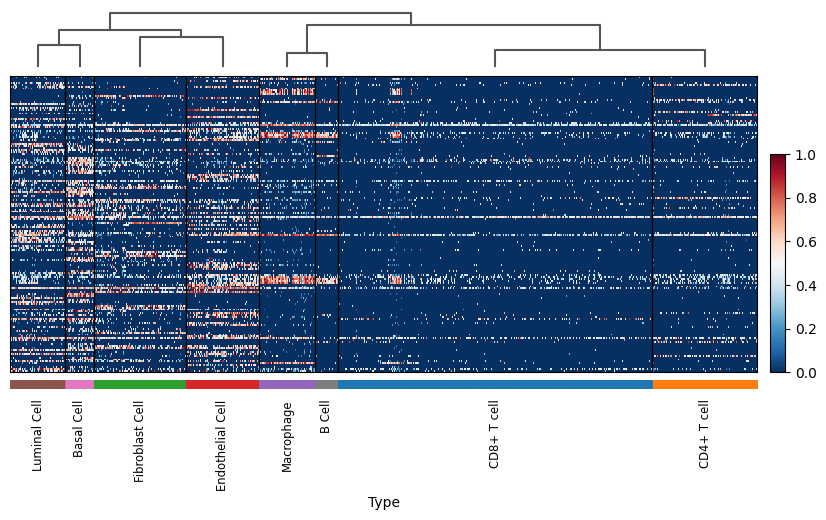

In [679]:
######################################################## genes that are present in both lists
genes_matched_w = matched_w.var_names.tolist()
genes_matched_s = matched.var_names.tolist()
print("Wilcoxon:", len(genes_matched_w))
print("SCVI:", len(matched.var_names.unique().tolist()))

########################################################
shared_genes = [gene for gene in genes_matched_w if gene in genes_matched_s]

print(f"Number of shared genes: {len(shared_genes)}")
print("Shared genes:", shared_genes)

########################################################
shared_matched = dat1[:, shared_genes]
shared_matched.var_names_make_unique()

######################################################## plot heatmap
sc.pl.heatmap(
    shared_matched,
    var_names=shared_genes,
    groupby="Type",
    use_raw=False,
    cmap='RdBu_r',          
    standard_scale='var',   ### based on z-score
    swap_axes=True,
    dendrogram=True,        ### based on hierarchical clustering
    save="heatmap_stats_scrnaseq.png"
)

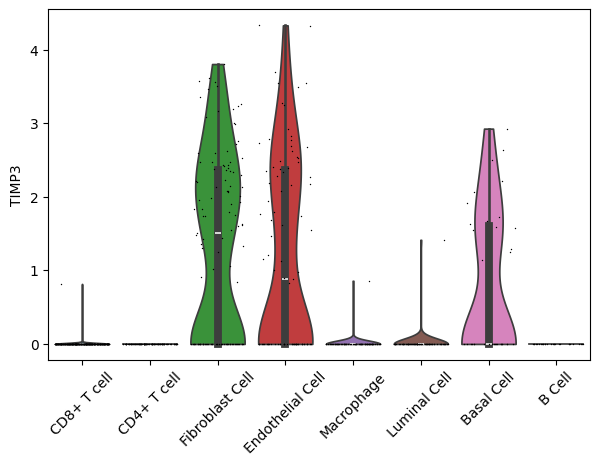

In [680]:
######################################################## check if TIMP3 is in the shared gene list
if "TIMP3" not in shared_genes:
    print("TIMP3 is not in the shared gene list.")
else:
    timp3_data = dat1[:, ["TIMP3"]].copy()
    
    #################################################### plot violin plot
    sc.pl.violin(timp3_data, keys="TIMP3", groupby="Type", rotation=45, scale="width", inner="box", jitter=0.4,
        save="violin_TIMP3.png"
    )